In [37]:
import pandas as pd

# Load dataset
df = pd.read_csv('dataset.csv', skiprows=32)

df = df[[
    'WOA_SSS', 'TEMP', 'LATITUDE', 'LONGITUDE',
    'PRESSURE_ATM', 'PRESSURE_EQUI',
    'DIST_TO_LAND', 'ETOPO2',
    'GVCO2',
    'YEAR', 'MONTH',
    'FCO2_RECOMMENDED'
]]
df.columns = [
    'Salinity', 'Temperature', 'Latitude', 'Longitude',
    'Pressure_atm', 'Pressure_equi',
    'Dist_to_land', 'Depth',
    'GVCO2',
    'Year', 'Month',
    'Target'
]

In [4]:
import numpy as np

df = df.replace([-1e34, -999], np.nan)
df = df.dropna()

In [39]:
df = df.drop_duplicates()

In [6]:
df = df[
    (df['Salinity'] > 0) & (df['Salinity'] <= 40) &
    (df['Temperature'] > -2) & (df['Temperature'] < 40) &
    (df['Target'] > 0) & (df['Target'] < 2000)
]

In [7]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [8]:
df = df.sort_values('Year')

train = df[df['Year'] < 2020]
test = df[df['Year'] >= 2020]

X_train = train.drop(columns=['Target'])
y_train = train['Target']

X_test = test.drop(columns=['Target'])
y_test = test['Target']

In [9]:

X = df.drop(columns=['Target'])
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [10]:
pip install PyCO2SYS


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 3.1 MB/s eta 0:00:00


In [11]:
import PyCO2SYS as pyco2
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_carbon_model(name, model, X_train, y_train, X_test_for_model, y_test, X_test_original=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_for_model)
    X_test_for_pyco2 = X_test_original if X_test_original is not None else X_test_for_model

    # Carbon Chemistry (PyCO2SYS)
    results = pyco2.sys(
        par1=y_pred[:10],
        par2=8.1,
        par1_type=4,
        par2_type=3,
        salinity=X_test_for_pyco2['Salinity'].iloc[:10], # Use original for PyCO2SYS
        temperature=X_test_for_pyco2['Temperature'].iloc[:10] # Use original for PyCO2SYS
    )

    # Extract ions
    hco3 = results['HCO3']
    co3 = results['CO3']
    co2 = results['CO2']
    ph = results['pH']
    dic = results['dic']

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)


    # Print
    print(f"\n--- {name} Results ---")
    print(f"HCO3- (first 3): {hco3[:3]}")
    print(f"CO3^2- (first 3): {co3[:3]}")
    print(f"CO2 (first 3): {co2[:3]}")
    print(f"pH (first 3): {ph[:3]}")
    print(f"DIC (first 3): {dic[:3]}")

    print(f"\nR2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print("-" * 30)
    return {
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "HCO3": results['HCO3'],
        "CO3": results['CO3'],
        "CO2": results['CO2']
    }

XGBoost Regressor

In [12]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

evaluate_carbon_model("XGBoost Regressor", xgb_model, X_train, y_train, X_test, y_test)


--- XGBoost Regressor Results ---
HCO3- (first 3): [2098.16643455 2081.23831234 2135.32264656]
CO3^2- (first 3): [343.60313688 343.98446824 353.94503624]
CO2 (first 3): [10.65601187 10.51686062 10.78419557]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2452.4255833  2435.7396412  2500.05187836]

R2 Score: 0.9634
RMSE: 0.8291
MAE: 0.5194
------------------------------


{'Model': 'XGBoost Regressor',
 'R2': 0.9633581792869401,
 'RMSE': np.float64(0.8290846718936248),
 'MAE': 0.519420905900315,
 'HCO3': array([2098.16643455, 2081.23831234, 2135.32264656, 2105.51185752,
        2121.14165915, 2081.84688342, 2096.46333797, 2084.64161898,
        2087.29367715, 2120.42613062]),
 'CO3': array([343.60313688, 343.98446824, 353.94503624, 352.60651328,
        349.30337227, 346.07689606, 343.14220631, 335.93672985,
        346.63338747, 350.843615  ]),
 'CO2': array([10.65601187, 10.51686062, 10.78419557, 10.58317733, 10.74818928,
        10.49664696, 10.65010408, 10.66876293, 10.53416721, 10.72070586])}

Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

evaluate_carbon_model("Random Forest (Base)", rf_model, X_train, y_train, X_test, y_test)


--- Random Forest (Base) Results ---
HCO3- (first 3): [2099.51529271 2081.38532817 2136.59992407]
CO3^2- (first 3): [343.82403065 344.00876684 354.15675414]
CO2 (first 3): [10.66286235 10.51760352 10.79064631]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.00218572 2435.91169853 2501.54732451]

R2 Score: 0.9715
RMSE: 0.7311
MAE: 0.4699
------------------------------


{'Model': 'Random Forest (Base)',
 'R2': 0.9715047350025757,
 'RMSE': np.float64(0.7311335504089097),
 'MAE': 0.46988348908296346,
 'HCO3': array([2099.51529271, 2081.38532817, 2136.59992407, 2106.59998213,
        2120.70352004, 2081.16298041, 2098.06802922, 2087.37403488,
        2087.43446894, 2119.65591307]),
 'CO3': array([343.82403065, 344.00876684, 354.15675414, 352.78873967,
        349.23122081, 345.96320709, 343.40485689, 336.37705439,
        346.65676853, 350.71617556]),
 'CO2': array([10.66286235, 10.51760352, 10.79064631, 10.58864669, 10.74596915,
        10.49319873, 10.65825597, 10.68274686, 10.53487776, 10.7168117 ])}

In [14]:
import pandas as pd
importance = rf_model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)

print(feat_imp)

Temperature      0.405936
Salinity         0.157800
Latitude         0.126842
Longitude        0.094666
Dist_to_land     0.088591
Depth            0.044312
Pressure_atm     0.041549
Pressure_equi    0.040304
GVCO2            0.000000
Year             0.000000
Month            0.000000
dtype: float64


KNN


In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
knn_model = KNeighborsRegressor(n_neighbors=5)


X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


evaluate_carbon_model(
    "KNN Regressor",
    knn_model,
    X_train_scaled,   # scaled input for model training
    y_train,
    X_test_scaled_df, # scaled input for model prediction
    y_test,
    X_test_original=X_test
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(



--- KNN Regressor Results ---
HCO3- (first 3): [2099.68208812 2081.56858577 2137.4649174 ]
CO3^2- (first 3): [343.85134566 344.03905542 354.30013298]
CO2 (first 3): [10.66370946 10.51852955 10.79501485]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.19714324 2436.12617074 2502.56006524]

R2 Score: 0.9526
RMSE: 0.9433
MAE: 0.6091
------------------------------


{'Model': 'KNN Regressor',
 'R2': 0.9525634770054919,
 'RMSE': np.float64(0.9433368234185832),
 'MAE': 0.6090934497816614,
 'HCO3': array([2099.68208812, 2081.56858577, 2137.4649174 , 2104.41737358,
        2120.05538193, 2079.55823977, 2096.54719332, 2088.75963589,
        2112.45729781, 2121.29417467]),
 'CO3': array([343.85134566, 344.03905542, 354.30013298, 352.4232219 ,
        349.12448734, 345.6964422 , 343.15593148, 336.60034182,
        350.81226808, 350.98724071]),
 'CO2': array([10.66370946, 10.51852955, 10.79501485, 10.57767599, 10.74268492,
        10.48510765, 10.65053007, 10.68983808, 10.66116313, 10.72509462])}

K-FOLD CV

In [16]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
knn_model = KNeighborsRegressor(n_neighbors=5)

# K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='r2'
)

print("KNN Cross-Val R2 Scores:", scores)
print("Mean R2:", np.mean(scores))
print("-" * 30)

# Final evaluation + ions
evaluate_carbon_model(
    "KNN Regressor",
    knn_model,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_test_original=X_test
)

KNN Cross-Val R2 Scores: [0.94505547 0.9527646  0.94970637 0.96394652 0.95065972]
Mean R2: 0.9524265356365482
------------------------------

--- KNN Regressor Results ---
HCO3- (first 3): [2099.68208812 2081.56858577 2137.4649174 ]
CO3^2- (first 3): [343.85134566 344.03905542 354.30013298]
CO2 (first 3): [10.66370946 10.51852955 10.79501485]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.19714324 2436.12617074 2502.56006524]

R2 Score: 0.9526
RMSE: 0.9433
MAE: 0.6091
------------------------------


{'Model': 'KNN Regressor',
 'R2': 0.9525634770054919,
 'RMSE': np.float64(0.9433368234185832),
 'MAE': 0.6090934497816614,
 'HCO3': array([2099.68208812, 2081.56858577, 2137.4649174 , 2104.41737358,
        2120.05538193, 2079.55823977, 2096.54719332, 2088.75963589,
        2112.45729781, 2121.29417467]),
 'CO3': array([343.85134566, 344.03905542, 354.30013298, 352.4232219 ,
        349.12448734, 345.6964422 , 343.15593148, 336.60034182,
        350.81226808, 350.98724071]),
 'CO2': array([10.66370946, 10.51852955, 10.79501485, 10.57767599, 10.74268492,
        10.48510765, 10.65053007, 10.68983808, 10.66116313, 10.72509462])}

LightGBM


In [17]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Model
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
# Final evaluation
evaluate_carbon_model(
    "LightGBM",
    lgbm_model,
    X_train,
    y_train,
    X_test,
    y_test,
    X_test_original=X_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1666
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 8
[LightGBM] [Info] Start training from score 428.357720

--- LightGBM Results ---
HCO3- (first 3): [2097.85510294 2081.94813605 2137.87166384]
CO3^2- (first 3): [343.55215212 344.10178702 354.36755412]
CO2 (first 3): [10.65443071 10.52044748 10.79706908]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2452.06168577 2436.57037056 2503.03628704]

R2 Score: 0.9690
RMSE: 0.7626
MAE: 0.4800
------------------------------


{'Model': 'LightGBM',
 'R2': 0.9690000307061366,
 'RMSE': np.float64(0.7625898053294757),
 'MAE': 0.4799535732108228,
 'HCO3': array([2097.85510294, 2081.94813605, 2137.87166384, 2104.06791509,
        2121.6982312 , 2080.98599466, 2097.32624255, 2086.46999039,
        2089.52233539, 2123.46010635]),
 'CO3': array([343.55215212, 344.10178702, 354.36755412, 352.36469868,
        349.39502692, 345.93378577, 343.28344369, 336.23136904,
        347.00349704, 351.34561363]),
 'CO2': array([10.65443071, 10.52044748, 10.79706908, 10.57591947, 10.75100952,
        10.49230637, 10.65448767, 10.67812015, 10.54541482, 10.7360454 ])}

CatBoost

In [18]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [19]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Model
cat_model = CatBoostRegressor(
    verbose=0,
    depth=6,
    learning_rate=0.05,
    iterations=500,
    random_state=42
)

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("CatBoost Cross-Val R2 Scores:", scores)
print("Mean R2:", np.mean(scores))
print("-" * 30)

# Final evaluation
evaluate_carbon_model(
    "CatBoost",
    cat_model,
    X_train,
    y_train,
    X_test,
    y_test,
    X_test_original=X_test
)

CatBoost Cross-Val R2 Scores: [0.96625102 0.97988654 0.97269042 0.97259221 0.97463484]
Mean R2: 0.9732110056993397
------------------------------

--- CatBoost Results ---
HCO3- (first 3): [2100.07047332 2081.25092969 2135.16525342]
CO3^2- (first 3): [343.91494899 343.98655362 353.91894719]
CO2 (first 3): [10.66568196 10.51692438 10.78340067]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.65110427 2435.75440769 2499.86760128]

R2 Score: 0.9792
RMSE: 0.6247
MAE: 0.4446
------------------------------


{'Model': 'CatBoost',
 'R2': 0.9791970254149237,
 'RMSE': np.float64(0.6247022678126857),
 'MAE': 0.4445859807446117,
 'HCO3': array([2100.07047332, 2081.25092969, 2135.16525342, 2105.43743369,
        2119.92424011, 2080.92730427, 2099.27053522, 2086.51321244,
        2092.96941825, 2121.12912606]),
 'CO3': array([343.91494899, 343.98655362, 353.91894719, 352.59404965,
        349.10289129, 345.92402935, 343.6016791 , 336.2383342 ,
        347.57594835, 350.95993193]),
 'CO2': array([10.66568196, 10.51692438, 10.78340067, 10.58280324, 10.7420204 ,
        10.49201045, 10.66436474, 10.67834135, 10.56281158, 10.72426015])}

MLP

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold
import numpy as np

# Drop features
X_train_mlp = X_train.drop(columns=['GVCO2', 'Year', 'Month'])
X_test_mlp = X_test.drop(columns=['GVCO2', 'Year', 'Month'])

#pipeline
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

#  K-Fold Cross Validation
kf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
scores = cross_val_score(
    mlp_pipeline,
    X_train_mlp,
    y_train,
    cv=kf,
    scoring='r2'
)

print("MLP Cross-Val R2 Scores:", scores)
print("Mean R2:", np.mean(scores))
print("-" * 30)

# Final evaluation

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_mlp)
X_test_scaled = scaler.transform(X_test_mlp)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    learning_rate_init=0.0003,
    alpha=0.001,
    max_iter=5000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42
)

evaluate_carbon_model(
    "MLP Regressor",
    mlp_model,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_test_original=X_test
)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

MLP Cross-Val R2 Scores: [ 0.21646111  0.80329208  0.56551229 -8.500529    0.72116811  0.22527966
  0.71491128  0.79826207  0.06287296  0.29182257 -0.19157604  0.37378833
  0.77604921 -2.15222962  0.83878764]
Mean R2: -0.29707515682759206
------------------------------

--- MLP Regressor Results ---
HCO3- (first 3): [2104.54968386 2083.17874862 2132.21519055]
CO3^2- (first 3): [344.64848031 344.30518113 353.42995313]
CO2 (first 3): [10.68843065 10.52666598 10.76850173]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2459.88659481 2438.01059573 2496.4136454 ]

R2 Score: 0.8908
RMSE: 1.4310
MAE: 1.0912
------------------------------


{'Model': 'MLP Regressor',
 'R2': 0.8908371399206395,
 'RMSE': np.float64(1.4310269612065483),
 'MAE': 1.0912277520429678,
 'HCO3': array([2104.54968386, 2083.17874862, 2132.21519055, 2116.54791487,
        2116.07002274, 2080.69834018, 2099.62468951, 2092.03030984,
        2094.53830747, 2130.33508691]),
 'CO3': array([344.64848031, 344.30518113, 353.42995313, 354.45470316,
        348.4681901 , 345.88596738, 343.65964591, 337.1274058 ,
        347.83649117, 352.48314113]),
 'CO2': array([10.68843065, 10.52666598, 10.76850173, 10.63864913, 10.72249042,
        10.49085602, 10.66616385, 10.70657671, 10.57072946, 10.77080475])}

In [21]:
all_results = []

all_results.append(
    evaluate_carbon_model("Random Forest", rf_model, X_train, y_train, X_test, y_test, X_test)
)

all_results.append(
    evaluate_carbon_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test, X_test)
)

all_results.append(
    evaluate_carbon_model("KNN", knn_model, X_train_scaled, y_train, X_test_scaled, y_test, X_test)
)

all_results.append(
    evaluate_carbon_model("MLP", mlp_model, X_train_scaled, y_train, X_test_scaled, y_test, X_test)
)

all_results.append(
    evaluate_carbon_model("LightGBM", lgbm_model, X_train, y_train, X_test, y_test, X_test)
)

all_results.append(
    evaluate_carbon_model("CatBoost", cat_model, X_train, y_train, X_test, y_test, X_test)
)


--- Random Forest Results ---
HCO3- (first 3): [2099.51529271 2081.38532817 2136.59992407]
CO3^2- (first 3): [343.82403065 344.00876684 354.15675414]
CO2 (first 3): [10.66286235 10.51760352 10.79064631]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.00218572 2435.91169853 2501.54732451]

R2 Score: 0.9715
RMSE: 0.7311
MAE: 0.4699
------------------------------

--- XGBoost Results ---
HCO3- (first 3): [2098.16643455 2081.23831234 2135.32264656]
CO3^2- (first 3): [343.60313688 343.98446824 353.94503624]
CO2 (first 3): [10.65601187 10.51686062 10.78419557]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2452.4255833  2435.7396412  2500.05187836]

R2 Score: 0.9634
RMSE: 0.8291
MAE: 0.5194
------------------------------

--- KNN Results ---
HCO3- (first 3): [2099.68208812 2081.56858577 2137.4649174 ]
CO3^2- (first 3): [343.85134566 344.03905542 354.30013298]
CO2 (first 3): [10.66370946 10.51852955 10.79501485]
pH (first 3): [8.1 8.1 8.1]
DIC (first 3): [2454.19714324 2436.12617074 2502.56006

In [23]:
import pandas as pd

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("R2", ascending=False)
df_results.to_csv("model_results.csv", index=False)

print(df_results[['Model', 'R2', 'RMSE', 'MAE']])

           Model        R2      RMSE       MAE
5       CatBoost  0.979197  0.624702  0.444586
0  Random Forest  0.971505  0.731134  0.469883
4       LightGBM  0.969000  0.762590  0.479954
1        XGBoost  0.963358  0.829085  0.519421
2            KNN  0.952563  0.943337  0.609093
3            MLP  0.890837  1.431027  1.091228


In [25]:
import pandas as pd
import numpy as np

rows = []

for res in all_results:
    rows.append({
        'Model': res['Model'],
        'HCO3': round(np.mean(res['HCO3']), 2),
        'CO3': round(np.mean(res['CO3']), 2),
        'CO2': round(np.mean(res['CO2']), 2)
    })

df_table = pd.DataFrame(rows)
df_table.to_csv("ion_results.csv", index=False)
print(df_table)

           Model     HCO3     CO3    CO2
0  Random Forest  2101.85  346.71  10.64
1        XGBoost  2101.21  346.61  10.64
2            KNN  2104.18  347.10  10.65
3            MLP  2104.98  347.23  10.65
4       LightGBM  2102.12  346.76  10.64
5       CatBoost  2102.27  346.78  10.64


In [ ]:
df_results.to_csv("model_comparison_results.csv", index=False)

Coorelation HeatMap

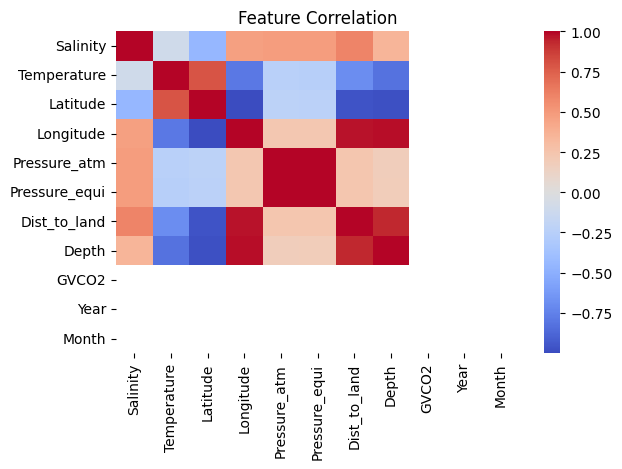

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

Feature Importance

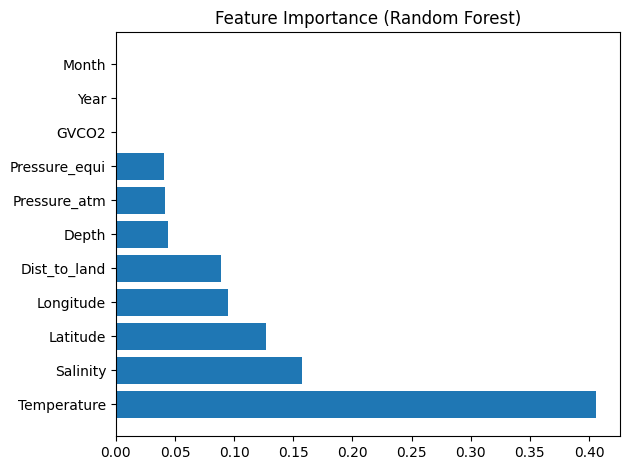

In [32]:
import pandas as pd

importances = rf_model.feature_importances_
features = X_train.columns

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

Model Comparision

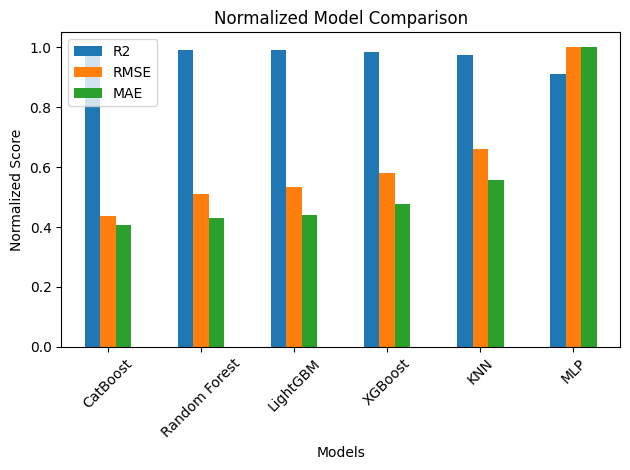

In [31]:
import matplotlib.pyplot as plt

df_norm = df_results.copy()

# Normalize
df_norm['R2'] = df_norm['R2'].clip(lower=0) / df_norm['R2'].max()
df_norm['RMSE'] = df_norm['RMSE'] / df_norm['RMSE'].max()
df_norm['MAE'] = df_norm['MAE'] / df_norm['MAE'].max()

# Plot
df_norm.plot(x='Model', y=['R2','RMSE','MAE'], kind='bar')

plt.title("Normalized Model Comparison")
plt.xlabel("Models")
plt.ylabel("Normalized Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ion Comparision Graph

 HCO₃⁻ distribution

/tmp/ipykernel_1927/2018089741.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(hco3_data, labels=models)


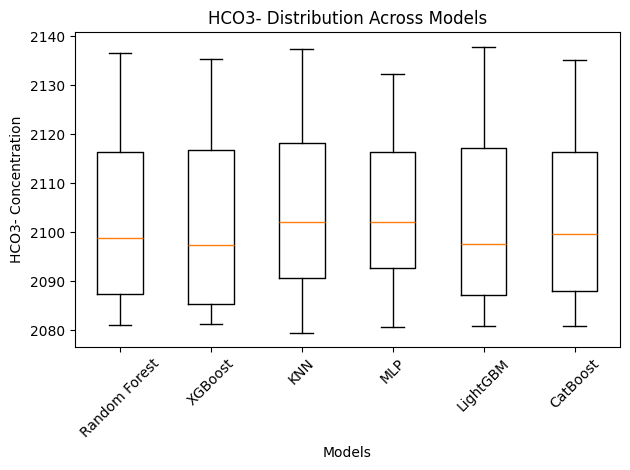

In [34]:
import matplotlib.pyplot as plt

models = [res['Model'] for res in all_results]
hco3_data = [res['HCO3'] for res in all_results]

plt.figure()
plt.boxplot(hco3_data, labels=models)
plt.xticks(rotation=45)
plt.title("HCO3- Distribution Across Models")
plt.xlabel("Models")
plt.ylabel("HCO3- Concentration")
plt.tight_layout()
plt.show()

CO₃²⁻ distribution

/tmp/ipykernel_1927/1718977203.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(co3_data, labels=models)


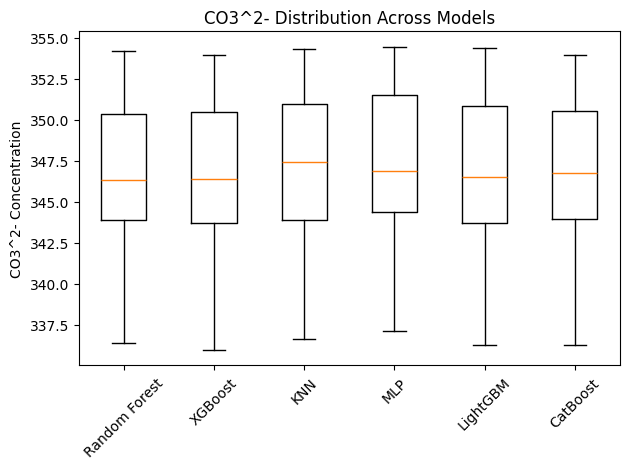

In [35]:
co3_data = [res['CO3'] for res in all_results]

plt.figure()
plt.boxplot(co3_data, labels=models)
plt.xticks(rotation=45)
plt.title("CO3^2- Distribution Across Models")
plt.ylabel("CO3^2- Concentration")
plt.tight_layout()
plt.show()

 CO₂ distribution

/tmp/ipykernel_1927/2738498169.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(co2_data, labels=models)


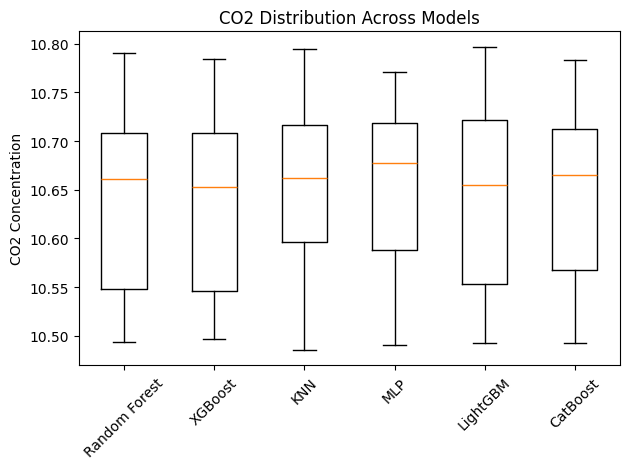

In [36]:
co2_data = [res['CO2'] for res in all_results]

plt.figure()
plt.boxplot(co2_data, labels=models)
plt.xticks(rotation=45)
plt.title("CO2 Distribution Across Models")
plt.ylabel("CO2 Concentration")
plt.tight_layout()
plt.show()

### Ion Comparison Table

In [29]:
import pandas as pd
import numpy as np

ion_comparison_data = []
for res in all_results:
    ion_comparison_data.append({
        'Model': res['Model'],
        'Mean HCO3': np.mean(res['HCO3']),
        'Mean CO3': np.mean(res['CO3']),
        'Mean CO2': np.mean(res['CO2'])
    })

df_ion_comparison = pd.DataFrame(ion_comparison_data)
display(df_ion_comparison)

,Model,Mean HCO3,Mean CO3,Mean CO2
0,Random Forest,2101.849947,346.712757,10.639162
1,XGBoost,2101.205256,346.607536,10.635882
2,KNN,2104.180489,347.099047,10.650935
3,MLP,2104.978829,347.229916,10.654987
4,LightGBM,2102.120572,346.757893,10.640525
5,CatBoost,2102.265793,346.781731,10.641262


Error Distribution

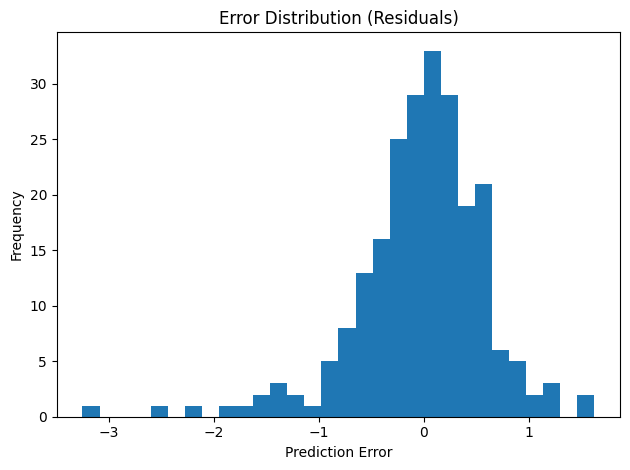

In [28]:
import matplotlib.pyplot as plt
import numpy as np


y_pred = cat_model.predict(X_test)
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.title("Error Distribution (Residuals)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Actual vs Predicted

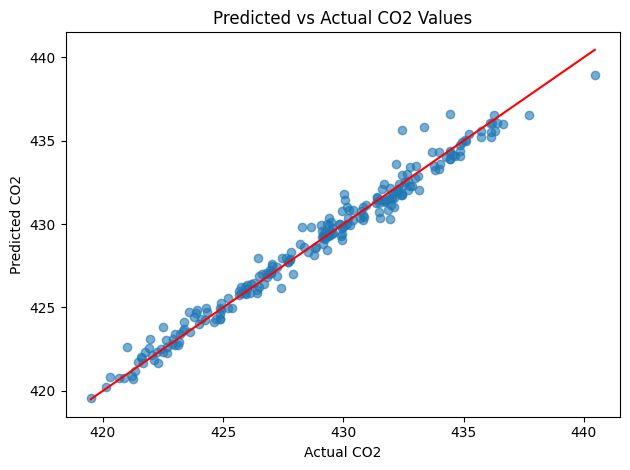

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

y_pred = cat_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')
pd.DataFrame({
    "Actual_CO2": y_test,
    "Predicted_CO2": y_pred
}).to_csv("predictions.csv", index=False)
plt.title("Predicted vs Actual CO2 Values")
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.tight_layout()
plt.show()